# Pascal Sentence 数据处理

In [1]:
import os
import os.path as osp
# save to id-map
P = "D:\\datasets"
IMAGE_P = osp.join(P, "vision.cs.uiuc.edu_files")


id_key = lambda x: int(x.split(".jpg")[0].split("2008_")[1])

img_files = os.listdir(IMAGE_P)
img_files = sorted(img_files, key=id_key)

with open(osp.join(P, "id-map.pascal-sentences.txt"), "w") as f:
    for sid, img_f in enumerate(img_files):
        f.write("{} {}\n".format(sid, img_f))

# show id-map.pascal-sentences.txt
with open(osp.join(P, "id-map.pascal-sentences.txt"), "r") as f:
    i = 0
    for line in f:
        if i > 10:
            break
        print(line)
        i+= 1

0 2008_000032.jpg

1 2008_000043.jpg

2 2008_000053.jpg

3 2008_000075.jpg

4 2008_000084.jpg

5 2008_000085.jpg

6 2008_000090.jpg

7 2008_000095.jpg

8 2008_000099.jpg

9 2008_000109.jpg

10 2008_000112.jpg



In [2]:
# get 20 categories from html <img> tag
from html.parser import HTMLParser
import numpy as np
HTML_F = osp.join(P, "vision.cs.uiuc.edu.html")


with open(HTML_F, "r") as f:
    html_txt = f.readlines()
# print(html_txt)
html_txt = "".join(html_txt)


class ParserLabel(HTMLParser):
    def __init__(self):
        HTMLParser.__init__(self)
        self.img_cls = {}
        self.class_set = set()

    def handle_starttag(self, tag, attrs):
        if "img" != tag:
            return
        assert len(attrs) == 1
        _cls, _img_f = attrs[0][1].split("/")
        # print(_cls, _img_f)
        self.class_set.add(_cls)
        self.img_cls[_img_f] = _cls


print("parse annotations")
parser = ParserLabel()
parser.feed(html_txt)

print("class order")
class_set = sorted(list(parser.class_set))
cls_id = {}
with open(osp.join(P, "class-name.pascal-sentences.txt"), "w") as f:
    for cid, c in enumerate(class_set):
        f.write("{} {}\n".format(cid, c))
        cls_id[c] = cid

# show id-map.pascal-sentences.txt
with open(osp.join(P, "class-name.pascal-sentences.txt"), "r") as f:
    i = 0
    for line in f:
        if i > 10:
            break
        print(line)
        i+= 1

parse annotations
class order
0 aeroplane

1 bicycle

2 bird

3 boat

4 bottle

5 bus

6 car

7 cat

8 chair

9 cow

10 diningtable



In [3]:
# mark each picture with label(0-19),save to npz(labels)
print("read sample order")
img_id = {}
with open(osp.join(P, "id-map.pascal-sentences.txt"), "r") as f:
    for line in f:
        line = line.strip()
        if line:
            sid, img_f = line.split()
            img_id[img_f] = int(sid)


print("label")
assert len(parser.img_cls) == len(img_id)
N_DATA = len(parser.img_cls)
print("#data:", N_DATA)  # 1000
labels = {}
for img, c in parser.img_cls.items():
    cid = cls_id[c]
    labels[img] = cid

# (1000,) 0 19 9.5 9500
print("labels:", len(labels))
with open(osp.join(P, "labels.pascal-sentences.txt"), "w") as f:
    for img, cid in labels.items():
        f.write("{} {}\n".format(img, cid))
          
# show labels.pascal-sentences.txt.txt
with open(osp.join(P, "labels.pascal-sentences.txt"), "r") as f:
    i = 0
    for line in f:
        if i % 100 != 0:
            continue
        print(line)
        i+= 100

read sample order
label
#data: 1000
labels: 1000
2008_000716.jpg 0

2008_001227.jpg 0

2008_001380.jpg 0

2008_001448.jpg 0

2008_001468.jpg 0

2008_001801.jpg 0

2008_001971.jpg 0

2008_001985.jpg 0

2008_002358.jpg 0

2008_002454.jpg 0

2008_003275.jpg 0

2008_003369.jpg 0

2008_003575.jpg 0

2008_003655.jpg 0

2008_003703.jpg 0

2008_003788.jpg 0

2008_003905.jpg 0

2008_004165.jpg 0

2008_004348.jpg 0

2008_004532.jpg 0

2008_005538.jpg 0

2008_005905.jpg 0

2008_005907.jpg 0

2008_005916.jpg 0

2008_006401.jpg 0

2008_006548.jpg 0

2008_006619.jpg 0

2008_006621.jpg 0

2008_006623.jpg 0

2008_006700.jpg 0

2008_006933.jpg 0

2008_007095.jpg 0

2008_007442.jpg 0

2008_007504.jpg 0

2008_007507.jpg 0

2008_007629.jpg 0

2008_008044.jpg 0

2008_008048.jpg 0

2008_008096.jpg 0

2008_008146.jpg 0

2008_008231.jpg 0

2008_008247.jpg 0

2008_008344.jpg 0

2008_008373.jpg 0

2008_008424.jpg 0

2008_008432.jpg 0

2008_008446.jpg 0

2008_008471.jpg 0

2008_008501.jpg 0

2008_008546.jpg 0

2

In [4]:
# get sentences of each picture, save to pascal-sentences_map.txt
with open(HTML_F, "r") as f:
    html_txt = f.readlines()
# print(html_txt)
html_txt = "".join(html_txt)


class ParserText(HTMLParser):
    def __init__(self):
        HTMLParser.__init__(self)
        self.tr_layer = 0
        self.current_img = None
        self.current_txt = []
        self.current_tag = None
        self.img_txt = {}

    def handle_starttag(self, tag, attrs):
        self.current_tag = tag
        if "img" == tag:
            assert len(attrs) == 1
            _cls, _img_f = attrs[0][1].split("/")
            # print(_cls, _img_f)
            self.current_img = _img_f
        elif "tr" == tag:
            self.tr_layer += 1

    def handle_endtag(self, tag):
        if "tr" == tag:
            self.tr_layer -= 1
            if 0 == self.tr_layer:
                self.current_txt = "$".join(self.current_txt)
                self.img_txt[self.current_img] = "$" + self.current_txt
                # print('\t', self.current_img, '\n', self.current_txt)
                self.current_img = None
                self.current_txt = []

        self.current_tag = None

    def handle_data(self, data):
        if (2 == self.tr_layer) and ("td" == self.current_tag):
            if data.endswith("."):
                    data = data[:-1]
            self.current_txt.append(data)


print("parse sentences")
parser = ParserText()
parser.feed(html_txt)

with open(osp.join(P, "pascal-sentences_map.txt"), "w") as f:
    for img, txt in parser.img_txt.items():
        f.write("{} {}\n".format(img, txt))
        
# show pascal-sentences_map.txt
with open(osp.join(P, "pascal-sentences_map.txt"), "r") as f:
    i = 0
    for line in f:
        if i > 10:
            break
        print(line)
        i+= 1

parse sentences
2008_000716.jpg $ One jet lands at an airport while another takes off next to it$ Two airplanes parked in an airport$ Two jets taxi past each other$ Two parked jet airplanes facing opposite directions$ two passenger planes on a grassy plain 

2008_001227.jpg $ Two gentleman talking in front of propeller plane$ Two men are conversing next to a small airplane$ Two men talking in front of a plane $ Two men talking in front of a small plane$ Two men talk while standing next to a small passenger plane at an airport

2008_001380.jpg $ A D-ERFW-6 in flight$ An army green plane flying in the sky$ An old fighter plane flying with German military markings$ A small green and yellow plane in the sky$ A WWII fighter plane with its landing gear down

2008_001448.jpg $ a larger plane in flying above a smaller plane $ Black and white scene of two planes flying$ Two airplanes in the sky$ Two fighter planes mid-flight$ Two military planes fly near each other

2008_001468.jpg $ A blue gro

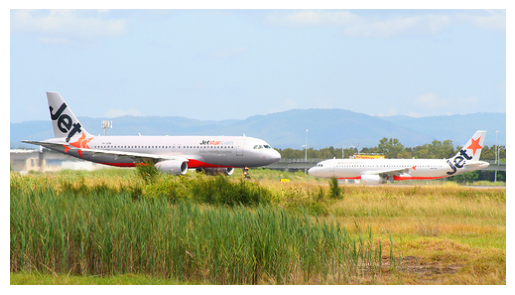

One jet lands at an airport while another takes off next to it
Two airplanes parked in an airport
Two jets taxi past each other
Two parked jet airplanes facing opposite directions
two passenger planes on a grassy plain


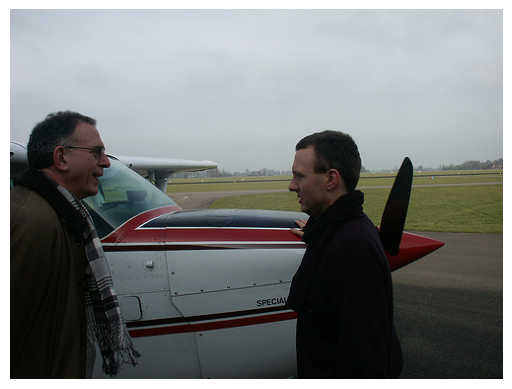

Two gentleman talking in front of propeller plane
Two men are conversing next to a small airplane
Two men talking in front of a plane
Two men talking in front of a small plane
Two men talk while standing next to a small passenger plane at an airport


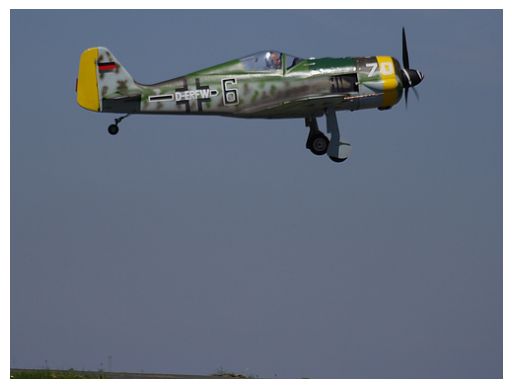

A D-ERFW-6 in flight
An army green plane flying in the sky
An old fighter plane flying with German military markings
A small green and yellow plane in the sky
A WWII fighter plane with its landing gear down


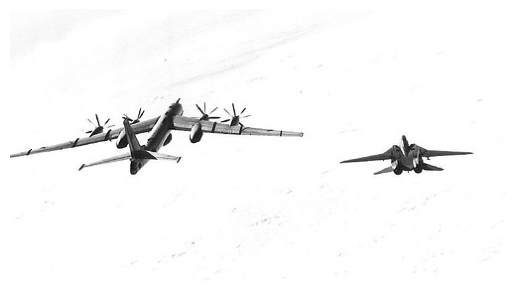

a larger plane in flying above a smaller plane
Black and white scene of two planes flying
Two airplanes in the sky
Two fighter planes mid-flight
Two military planes fly near each other


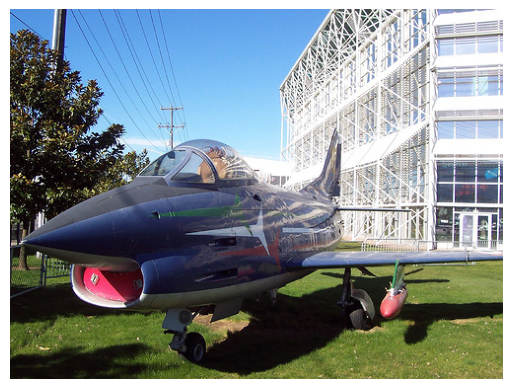

A blue grounded fighter jet is parked on grass in front of a glass building
A blue jet stopped on a lawn
A fighter jet sits on display
A jet plane on exhibit in front of a modern building
Blue fighter jet parked in the green grass


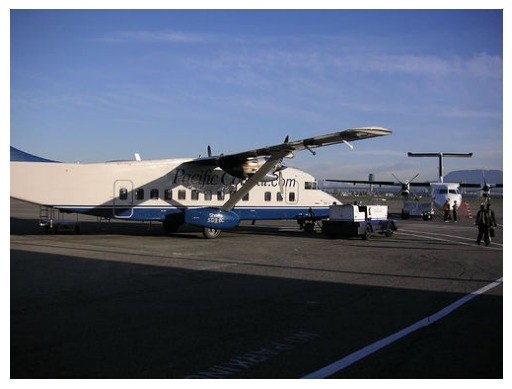

An airplane sitting on the tarmac at an airport with another plane in the background
A white an blue airplane parked at the airport near another small plane
Blue and white airplane parked
two airplanes are waiting on the tarmac
Two airplanes parked at the airport


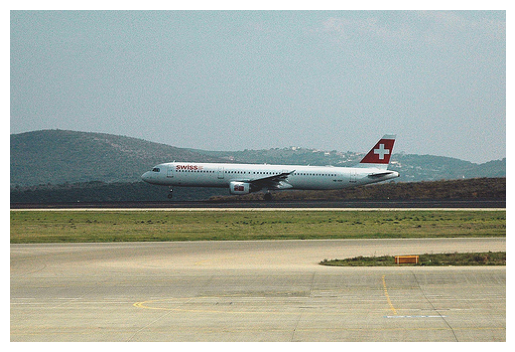

An airplane approaches a runway
An Swiss-Air flight has just taken off from a runway
A white Swiss airplane approaches the runway
The Swiss airline arrives safely
The white airplane is flying


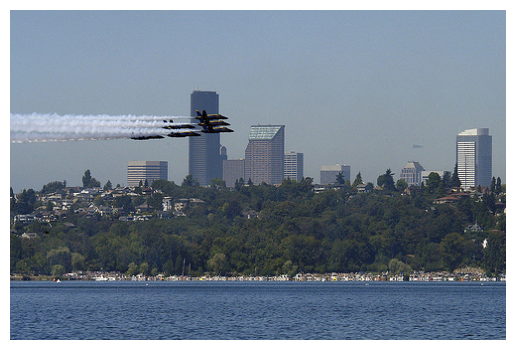

Fighter jet formation flying over lake
Five jets screech across the sky at low altitude above a river in a small city
Jets flying across the sky over the water by a city
Six jets are flying over the ocean
The Blue Angels flying over a river with a skyline in the background


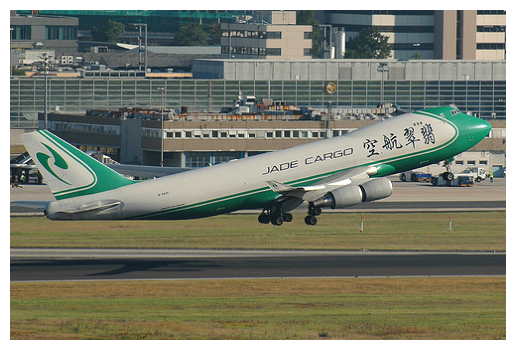

A green and gray plane is taking off from the runway
A green and white cargo plane taking of from an airport
A green and white jet taking off
A Jade Cargo jet in green and white taking off from an airport
White and green commercial airliner taking off of runway


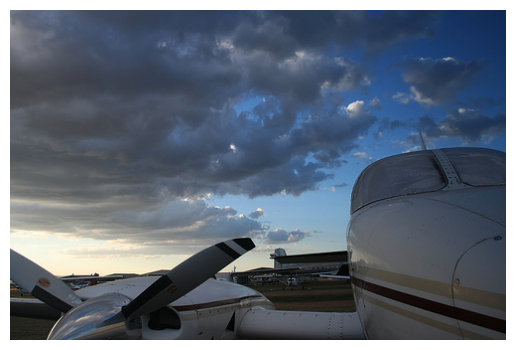

A small plane parked at an airfield with a cloudy sky overhead
A small white plane parked in an airport on a cloudy day
Close up of plane grounded at the airport
Propeller plane parked on runway at sunset
The right front of a twin engine propeller driven airplane


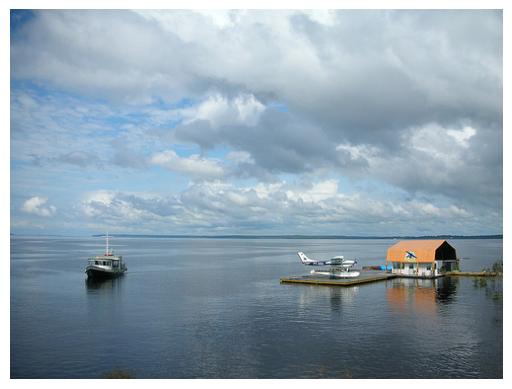

A boat is in the water and a small airplane is on the dock
A boat is on the water near a small plane
A small boat passes near a sea plane parked at the dock house
Boat in water with a seaplane landed on a platform by a orange roofed building
Plane parked on deck with boat gliding through the water


In [5]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
def img_text_show():
    with open(osp.join(P, "pascal-sentences_map.txt"), "r") as f:
        i = 0
        for line in f:
            if i > 10:
                break
            i += 1
            img_name = line.split("$")[0].strip()
            sentences = line.split("$")[1:]
            sentences = [s.strip() for s in sentences]
            #cv_img = cv2.imread(osp.join(IMAGE_P, img_name))
            plt_img = plt.imread(osp.join(IMAGE_P, img_name))
            plt.subplots()
            plt.imshow(plt_img)
            plt.axis("off")
            plt.show()
            for s in sentences:
                print(s)
img_text_show()

# faster rcnn 运行结果

torch.Size([3, 278, 500])
(278, 500, 3)


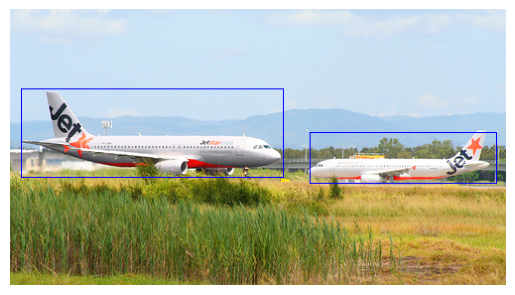

torch.Size([3, 375, 500])
(375, 500, 3)


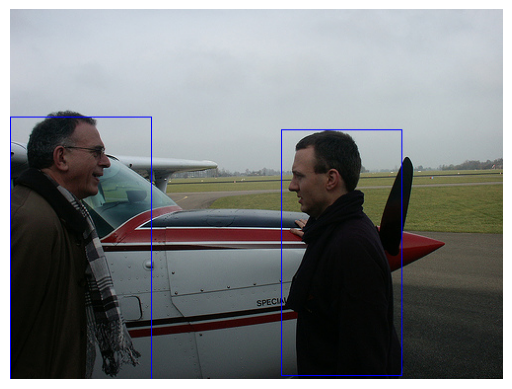

torch.Size([3, 375, 500])
(375, 500, 3)


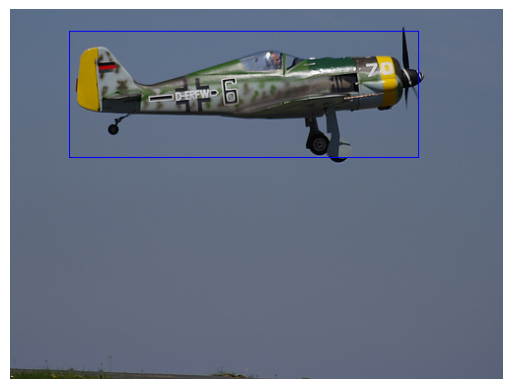

torch.Size([3, 274, 500])
(274, 500, 3)


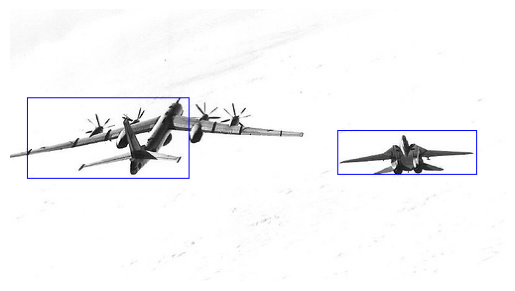

torch.Size([3, 375, 500])
(375, 500, 3)


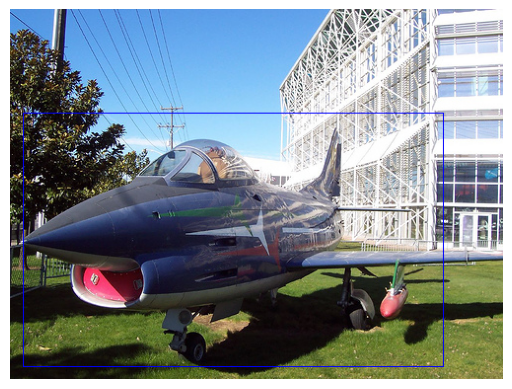

torch.Size([3, 375, 500])
(375, 500, 3)


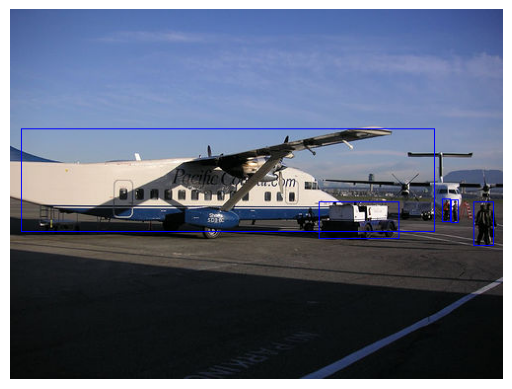

torch.Size([3, 335, 500])
(335, 500, 3)


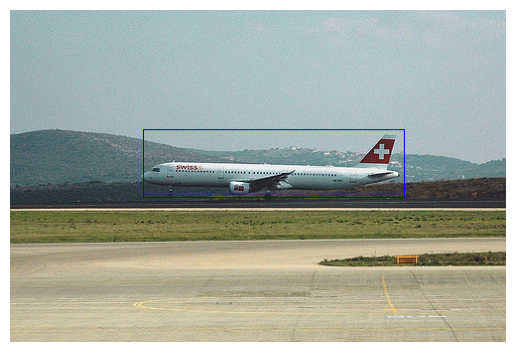

torch.Size([3, 333, 500])
(333, 500, 3)


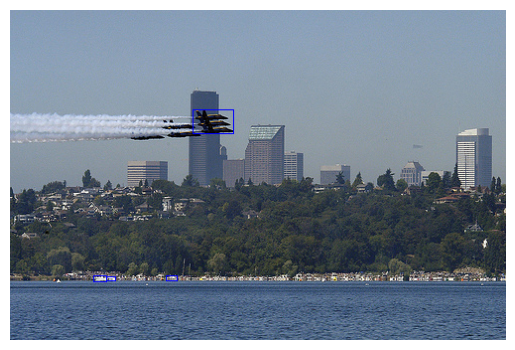

torch.Size([3, 333, 500])
(333, 500, 3)


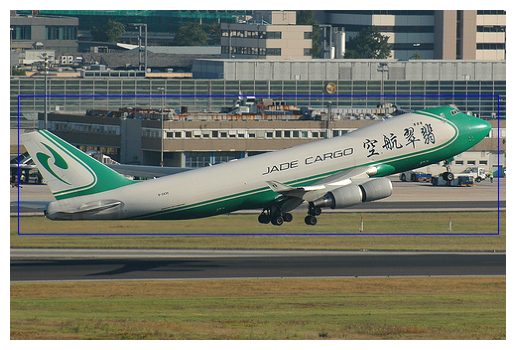

torch.Size([3, 333, 500])
(333, 500, 3)


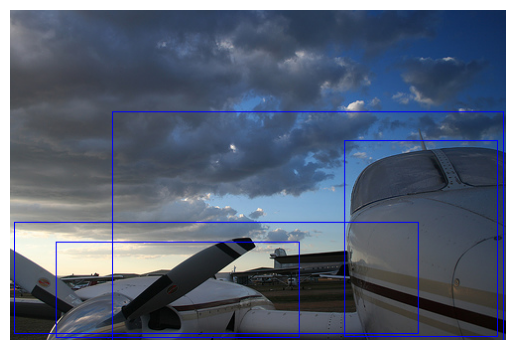

torch.Size([3, 375, 500])
(375, 500, 3)


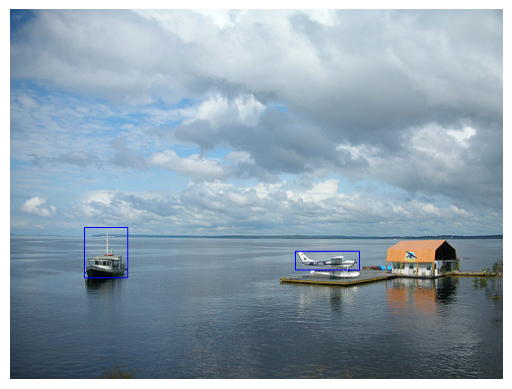

In [8]:
import torch
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from torchvision.utils import draw_bounding_boxes
def show_faster_rcnn_detection():
    model = fasterrcnn_resnet50_fpn(weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT)
    model.eval()
    show_list = []
    with open(osp.join(P, "pascal-sentences_map.txt"), "r") as f:
        i = 0
        for line in f:
            if i > 10:
                break
            i += 1
            img_name = line.split("$")[0].strip()
            show_list.append(img_name)
    for im_name in show_list:
        im_path = osp.join(IMAGE_P, im_name)
        im = cv2.imread(im_path)
        im = np.transpose(im, (2, 0, 1))
        im_tensor = torch.tensor(im, dtype=torch.float) / 255
        prediction = model([im_tensor])
        boxes = prediction[0]['boxes']
        score = prediction[0]['scores']
        boxes = boxes[score > 0.7]
        draw_image = draw_bounding_boxes(torch.tensor(im), boxes, colors='red')
        print(draw_image.shape)
        draw_image = draw_image.numpy(force=True)
        draw_image = np.transpose(draw_image, (1, 2, 0))
        print(draw_image.shape)
        plt.subplots()
        plt.axis("off")
        plt.imshow(cv2.cvtColor(draw_image, cv2.COLOR_BGR2RGB))
        plt.show()
show_faster_rcnn_detection()

# Pascal_sentences数据特征提取处理

In [9]:
def pascal_sentences_preprocess():
    img_list = []
    txt_list = []
    with open(osp.join(P, "pascal-sentences_map.txt"), "r") as f:
        for line in f:
            img_name = line.split("$")[0].strip()
            sentences = line.split("$")[1:]
            sentences = [s.strip() for s in sentences]
            img_list.append(img_name)
            txt_list.append(sentences)
    return img_list, txt_list
img_list, txt_list = pascal_sentences_preprocess()
print(img_list[-1], txt_list[-1])

2008_008524.jpg ['A group of people in a living room', 'A group of people, most likely a family siting in a living room', 'A group of people posing for a picture in a living room', 'A large gathering of people crowd into this small living room for a photo-op', 'This room is full of people sitting on the sofa, standing, and sitting on the floor']


In [28]:
# bert 特征保存
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
img_list, txt_list = pascal_sentences_preprocess()
from tqdm import tqdm
import time
from transformers import BertTokenizer, BertModel
def bert(img_list, txt_list):
    max_len = 48
    tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
    model = BertModel.from_pretrained("bert-base-uncased")
    model.to(device)
    for img_name, sentences in tqdm(zip(img_list, txt_list)):
        prefix = img_name[:-4]
#         if len(sentences) > 5:
#             print(sentences)
        for ix, sentence in enumerate(sentences):
            encoded_inputs = tokenizer(sentence, return_tensors='pt')
            input_ids = encoded_inputs["input_ids"]
            _, li = input_ids.shape
            pad_tensor = torch.zeros((1, max_len - li), dtype=torch.int64)
            input_ids = torch.concat((input_ids, pad_tensor), 1).to(device)
            attention_mask = encoded_inputs["attention_mask"]
            attention_mask = torch.concat((attention_mask, pad_tensor), 1).to(device)
            outputs= model(input_ids, attention_mask=attention_mask)

            last_hidden_state = outputs['last_hidden_state'].detach().cpu().numpy()

            pooler_output = outputs['pooler_output'].detach().cpu().numpy()
            bert_txt_name = prefix + "_" + str(ix) + ".npz"
            np.savez(osp.join(P, "text_features",bert_txt_name),
                     last_hidden_state=last_hidden_state, pooler_output=pooler_output, prefix=prefix)
st = time.time()
bert(img_list, txt_list)
et = time.time()
print("speed time: ", et - st)

1000it [01:30, 10.99it/s]

speed time:  92.84511470794678


In [75]:
# faster rcnn 特征保存
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
img_list, txt_list = pascal_sentences_preprocess()

def forward_hook(module, inputs, outputs):
    outputs = outputs.detach().to("cpu").numpy()
    im_name = img_list.pop(0)
    npy_name = osp.join(P, "image_features", im_name[:-4]+".npy")
    np.save(npy_name, outputs)
    
def faster_rcnn(img_list, device):
    model = fasterrcnn_resnet50_fpn(weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT)
    model.to(device)
    model.eval()
    #通过forward_hook截取fc6层的特征，shape(1000,1024)
    model.roi_heads.box_head.fc6.register_forward_hook(forward_hook)
    img_len = len(img_list)
    for _ in tqdm(range(img_len)):
        im_path = osp.join(IMAGE_P, img_list[0])
        im = cv2.imread(im_path)
        im = np.transpose(im, (2, 0, 1))
        im_tensor = torch.tensor(im, dtype=torch.float) / 255
        im_tensor = im_tensor.to(device)
        prediction = model([im_tensor])
        
faster_rcnn(img_list, device)

100%|██████████| 1000/1000 [01:32<00:00, 10.81it/s]


In [29]:
import numpy as np
import os
txt_fea_dir = "D:\\datasets\\text_features"
img_fea_dir = "D:\\datasets\\image_features"
txt_fea_file = os.listdir(txt_fea_dir)
print(len(txt_fea_file))
for f in txt_fea_file:
    tf_file = os.path.join(txt_fea_dir, f)
    tf_dict = np.load(tf_file)
    prefix = str(tf_dict['prefix'])
    if_file = os.path.join(img_fea_dir, prefix+".npy")
    if_array = np.load(if_file)
    for k,v in tf_dict.items():
        print(k, v.shape)
    break

4998
last_hidden_state (1, 48, 768)
pooler_output (1, 768)
prefix ()


# 基于图像-文本的Transformer(Encode) 结构

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

d_model = 512  # Embedding Size
d_ff = 2048  # FeedForward dimension
d_k = d_v = 64  # dimension of K(=Q), V
n_layers = 6  # number of Encoder of Decoder Layer
n_heads = 8  # number of heads in Multi-Head Attention

img_dim = 1024
proposals = 1000
txt_len = 48
txt_dim = 768
num_classes = 20

class ScaledDotProductAttention(nn.Module):
    def __init__(self):
        super(ScaledDotProductAttention, self).__init__()

    def forward(self, Q, K, V):
        scores = torch.matmul(Q, K.transpose(-1, -2)) / np.sqrt(d_k) # scores : [batch_size x n_heads x len_q(=len_k) x len_k(=len_q)]
        attn = nn.Softmax(dim=-1)(scores)
        context = torch.matmul(attn, V)
        return context, attn

class MultiHeadAttention(nn.Module):
    def __init__(self):
        super(MultiHeadAttention, self).__init__()
        self.W_Q = nn.Linear(d_model, d_k * n_heads)
        self.W_K = nn.Linear(d_model, d_k * n_heads)
        self.W_V = nn.Linear(d_model, d_v * n_heads)
        self.linear = nn.Linear(n_heads * d_v, d_model)
        self.layer_norm = nn.LayerNorm(d_model)

    def forward(self, Q, K, V):
        # q: [batch_size x len_q x d_model], k: [batch_size x len_k x d_model], v: [batch_size x len_k x d_model]
        residual, batch_size = Q, Q.size(0)
        # (B, S, D) -proj-> (B, S, D) -split-> (B, S, H, W) -trans-> (B, H, S, W)
        q_s = self.W_Q(Q).view(batch_size, -1, n_heads, d_k).transpose(1,2)  # q_s: [batch_size x n_heads x len_q x d_k]
        k_s = self.W_K(K).view(batch_size, -1, n_heads, d_k).transpose(1,2)  # k_s: [batch_size x n_heads x len_k x d_k]
        v_s = self.W_V(V).view(batch_size, -1, n_heads, d_v).transpose(1,2)  # v_s: [batch_size x n_heads x len_k x d_v]

        #attn_mask = attn_mask.unsqueeze(1).repeat(1, n_heads, 1, 1) # attn_mask : [batch_size x n_heads x len_q x len_k]

        # context: [batch_size x n_heads x len_q x d_v], attn: [batch_size x n_heads x len_q(=len_k) x len_k(=len_q)]
        context, attn = ScaledDotProductAttention()(q_s, k_s, v_s)
        context = context.transpose(1, 2).contiguous().view(batch_size, -1, n_heads * d_v) # context: [batch_size x len_q x n_heads * d_v]
        output = self.linear(context)
        return self.layer_norm(output + residual), attn # output: [batch_size x len_q x d_model]

class PoswiseFeedForwardNet(nn.Module):
    def __init__(self):
        super(PoswiseFeedForwardNet, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=d_model, out_channels=d_ff, kernel_size=1)
        self.conv2 = nn.Conv1d(in_channels=d_ff, out_channels=d_model, kernel_size=1)
        self.layer_norm = nn.LayerNorm(d_model)

    def forward(self, inputs):
        residual = inputs # inputs : [batch_size, len_q, d_model]
        output = nn.ReLU()(self.conv1(inputs.transpose(1, 2)))
        output = self.conv2(output).transpose(1, 2)
        return self.layer_norm(output + residual)    

class EncoderLayer(nn.Module):
    def __init__(self):
        super(EncoderLayer, self).__init__()
        self.enc_self_attn = MultiHeadAttention()
        self.pos_ffn = PoswiseFeedForwardNet()

    def forward(self, Q, K, V):
        enc_outputs, attn = self.enc_self_attn(Q, K, V) # enc_inputs to same Q,K,V
        enc_outputs = self.pos_ffn(enc_outputs) # enc_outputs: [batch_size x len_q x d_model]
        return enc_outputs, attn

class Encoder(nn.Module):
    def __init__(self):
        super(Encoder, self).__init__()
        self.layers = nn.ModuleList([EncoderLayer() for _ in range(n_layers)])

    def forward(self, Q, K, V): # enc_inputs : [batch_size x source_len x feature_dim]
        enc_self_attns = []
        for layer in self.layers:
            enc_outputs, enc_self_attn = layer(Q, K, V)
            enc_self_attns.append(enc_self_attn)
        return enc_outputs, enc_self_attns

class Image_Align(nn.Module):
    def __init__(self):
        super(Image_Align, self).__init__()
        self.conv = nn.Conv1d(img_dim, d_model, kernel_size=1)
#         self.dim_fc = nn.Linear(proposals, txt_len)
        
    def forward(self, image_feature):
        img_align_feature = self.conv(image_feature.transpose(1, 2))
#         img_align_feature = self.dim_fc(img_align_feature)
        return img_align_feature.transpose(1, 2) #(1000, d_model)
        
    
class Text_Align(nn.Module):
    def __init__(self):
        super(Text_Align, self).__init__()
        self.conv = nn.Conv1d(txt_dim, d_model, kernel_size=1)
        
    def forward(self, text_feature):
        text_align_feature = self.conv(text_feature.transpose(1, 2)) 
        return text_align_feature.transpose(1, 2)  # (48, d_model)

class CGSA(nn.Module):
    def __init__(self):
        super(CGSA, self).__init__()
        self.image_align = Image_Align()
        
        self.text_align = Text_Align()
        self.vatt_encoder = Encoder()
        self.tatt_encoder = Encoder()
        self.vt_encoder = Encoder()
        self.tv_encoder = Encoder()
        
        self.vatt_fc = nn.Linear(d_model, d_model)
        self.tatt_fc = nn.Linear(d_model, d_model)
        self.vt_fc = nn.Linear(d_model, d_model)
        self.tv_fc = nn.Linear(d_model, d_model)
        
        self.sampler1 = nn.Linear(proposals, txt_len)
        self.sampler2 = nn.Linear(proposals, txt_len)
        
        self.pred1 = nn.Linear(txt_len*txt_len, num_classes)
        self.pred2 = nn.Linear(txt_len*txt_len, num_classes)
        self.pred3 = nn.Linear(txt_len*txt_len, num_classes)
        self.pred4 = nn.Linear(txt_len*txt_len, num_classes)
        self.global_pred = nn.Linear(txt_len*txt_len, num_classes)
        
        
    def forward(self, image_fea, text_fea):
        cur_batch, _, _ = image_fea.shape
        img_align_fea  = self.image_align(image_fea)  #(batchsize, 1000, d_model)
        txt_align_fea = self.text_align(text_fea)    #(batchsize, 48, d_model)
        
        # Q, K, V , (batchsize, 1000, d_model)
        f_vatt, _= self.vatt_encoder(img_align_fea, img_align_fea, img_align_fea) 
        #                (batchsize, 48, d_model)
        f_tatt, _ = self.tatt_encoder(txt_align_fea, txt_align_fea, txt_align_fea) 
        # text-guided,text features for Q ,(batchsize, 48, d_model)
        f_tv, _ = self.tv_encoder(f_tatt, f_vatt, f_vatt) 
        # image-guided,image features for Q,(batchsize, 1000, d_model)
        f_vt, _ = self.vt_encoder(f_vatt, f_tatt, f_tatt) 
        
        #The sampling layer will sampler these four features to ensure the same dimentionality for fusion
        f_vatt = self.sampler1(f_vatt.transpose(1, 2)).transpose(1, 2)   #(batchsize, 48, d_model)
        f_vt = self.sampler2(f_vt.transpose(1, 2)).transpose(1, 2)   #(batchsize, 48, d_model)
        
        f_vatt_hat = F.relu(self.vatt_fc(f_vatt))  
        f_tatt_hat = F.relu(self.tatt_fc(f_tatt))  
        f_vt_hat = F.relu(self.vt_fc(f_vt))        
        f_tv_hat= F.relu(self.tv_fc(f_tv))         
        
        f_tatt_vatt = torch.matmul(f_tatt_hat, f_vatt_hat.transpose(-1, -2)) #(batchsize, 48, 48)
        f_vatt_vt = torch.matmul(f_vatt_hat, f_vt_hat.transpose(-1, -2))
        f_tatt_tv = torch.matmul(f_tatt_hat, f_tv_hat.transpose(-1, -2))
        f_tv_vt = torch.matmul(f_tv_hat, f_vt_hat.transpose(-1, -2))
        
        f_global = torch.matmul(f_tatt_vatt, torch.matmul(f_vatt_vt, torch.matmul(f_tatt_tv, f_tv_vt)))
        
        # first thress layers using softmax to get prediction result y_pre1, y_pre2, y_pre3
        f_tatt_vatt_flat = f_tatt_vatt.view(cur_batch, -1)
        y_pre1 = self.pred1(f_tatt_vatt_flat)
        f_vatt_vt_flat = f_vatt_vt.view(cur_batch, -1)
        y_pre2 = self.pred2(f_vatt_vt_flat)
        f_tatt_tv_flat = f_tatt_tv.view(cur_batch, -1)
        y_pre3 = self.pred3(f_tatt_tv_flat)
        
        # global feature as final fused feature result
        f_global_flat = f_global.view(cur_batch, -1)
        f_glabal_pred = self.global_pred(f_global_flat)
        pred_list = [y_pre1, y_pre2, y_pre3]
        
        return pred_list, f_glabal_pred
        

# pascal_sentences dataset

In [94]:
# 90% for training and 10% for validate(test)
import os
import shutil
label_file = "D:\\datasets\\labels.pascal-sentences.txt"
text_feature_dir = "D:\\datasets\\text_features"
image_feature_dir = "D:\\datasets\\image_features"
img_val_dir = "D:\\datasets\\image_val_features"
txt_val_dir = "D:\\datasets\\text_val_features"
txt_files = os.listdir(text_feature_dir)
target_dict = {}
with open(label_file, "r") as f:
    for line in f:
        k, v = line.split(" ")
        k = k[:-4]
        target_dict[k] = int(v)
count_dict = {}
for i in range(20):
    count_dict[i] = 0
train_list = []
val_list = []
for k,v in target_dict.items():
    if v in count_dict and count_dict[v] < 45:
        count_dict[v] += 1
        train_list.append(k)
    else:
        val_list.append(k)
print(len(train_list))
print(len(val_list))
img_val_list = []
txt_val_list = []
for prefix in val_list:
    img_val_file = prefix + ".npy"
    img_val_list.append(img_val_file)
    for t_f in txt_files:
        if t_f.startswith(prefix):
            txt_val_list.append(t_f)
print(len(img_val_list))
print(len(txt_val_list))
print(img_val_list[-1])
print(txt_val_list[-1])
for im_f in img_val_list:
    shutil.move(os.path.join(image_feature_dir, im_f), os.path.join(img_val_dir, im_f))
for tx_f in txt_val_list:
    shutil.move(os.path.join(text_feature_dir, tx_f), os.path.join(txt_val_dir, tx_f))

900
100
100
499
2008_008524.npy
2008_008524_4.npz


In [3]:
import torch.utils.data as data
import os
import numpy as np
class PascalSentencesDataset(data.Dataset):
    def __init__(self, state="train"):
        if state == "train":
            self.text_feature_dir = "D:\\datasets\\text_features"
            self.image_feature_dir = "D:\\datasets\\image_features"
        elif state == "val":
            self.text_feature_dir = "D:\\datasets\\text_val_features"
            self.image_feature_dir = "D:\\datasets\\image_val_features"
        else:
            raise NotImplemntExcetion()
        self.label_file = "D:\\datasets\\labels.pascal-sentences.txt"
        self.file_list = os.listdir(self.text_feature_dir)
        self.target_dict = {}
        with open(self.label_file, "r") as f:
            for line in f:
                k, v = line.split(" ")
                k = k[:-4]
                self.target_dict[k] = int(v)
        
    def __getitem__(self, index):
        tf_file = os.path.join(self.text_feature_dir, self.file_list[index])
        tf_dict = np.load(tf_file)
        prefix = str(tf_dict['prefix'])
        if_file = os.path.join(self.image_feature_dir, prefix+".npy")
        img_input = torch.tensor(np.load(if_file))
        txt_input = np.squeeze(tf_dict['last_hidden_state'], 0)
        txt_input = torch.tensor(txt_input)
        tar_num = self.target_dict[prefix]
        target = torch.zeros(20)
        target[tar_num] = 1
        return img_input, txt_input, target
        
    def __len__(self):
        return len(self.file_list)
        

In [3]:
train_dataset = PascalSentencesDataset(state="train")
train_dataloader = data.DataLoader(train_dataset, batch_size = 22, shuffle = True)
for img_input, txt_input, target in train_dataloader:
    print(img_input.shape, img_input.dtype)
    print(txt_input.shape, txt_input.dtype)
    print(target.dtype, target.shape)
    break

torch.Size([22, 1000, 1024]) torch.float32
torch.Size([22, 48, 768]) torch.float32
torch.float32 torch.Size([22, 20])


In [4]:
val_dataset = PascalSentencesDataset(state="val")
val_dataloader = data.DataLoader(val_dataset, batch_size = 22, shuffle = False)
for img_input, txt_input, target in val_dataloader:
    print(img_input.shape, img_input.dtype)
    print(txt_input.shape, txt_input.dtype)
    print(target.dtype, target.shape)
    break

torch.Size([22, 1000, 1024]) torch.float32
torch.Size([22, 48, 768]) torch.float32
torch.float32 torch.Size([22, 20])


# 训练过程

In [6]:
import torch.optim as optim
import torch.nn.functional as F
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
n_epochs = 20
model = CGSA().to(device)
l1 = nn.CrossEntropyLoss().to(device)
l2 = nn.CrossEntropyLoss().to(device)
l3 = nn.CrossEntropyLoss().to(device)
l4 = nn.CrossEntropyLoss().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-5)
for epoch in range(n_epochs):
    for ix, batch in enumerate(train_dataloader):
        optimizer.zero_grad()
        batch = [b.to(device) for b in batch]
        image_fea, text_fea, target = batch
        y_pred_list, f_glabal_pred = model(image_fea, text_fea)
        y_pre1, y_pre2, y_pre3 = y_pred_list
        loss1 = l1(y_pre1, target)
        loss2 = l2(y_pre2, target)
        loss3 = l3(y_pre3, target)
#         loss4 = l4(f_glabal_pred, target)
        loss = (loss1 + loss2 + loss3) / 3.
        
        acc_target = torch.argmax(target, dim=1)
        
        y_pre1_sft = F.softmax(y_pre1, dim=1)
        y_pre1_arg = torch.argmax(y_pre1_sft, dim=1)
        y_pre1_acc = torch.sum(y_pre1_arg == acc_target) / torch.sum(torch.ones(acc_target.shape))
#         y_pre1_acc.to("cpu").numpy()
        
        y_pre2_sft = F.softmax(y_pre2, dim=1)
        y_pre2_arg = torch.argmax(y_pre2_sft, dim=1)
        y_pre2_acc = torch.sum(y_pre2_arg == acc_target) / torch.sum(torch.ones(acc_target.shape))

        y_pre3_sft = F.softmax(y_pre3, dim=1)
        y_pre3_arg = torch.argmax(y_pre3_sft, dim=1)
        y_pre3_acc = torch.sum(y_pre3_arg == acc_target) / torch.sum(torch.ones(acc_target.shape))
#         y_pre3_acc.to("cpu").numpy()
        
#         y_global_sft = F.softmax(f_glabal_pred, dim=1)
#         y_global_arg = torch.argmax(y_global_sft, dim=1)
#         y_global_tar = target[y_global_arg]
#         y_global_acc = torch.sum(y_global_tar) / torch.sum(torch.ones(target.shape))
#         y_global_acc.to("cpu").numpy()

        #print loss
        if ix % 100 == 0:
            print('Epoch: {:04d}'.format(epoch + 1), 'loss1 = {:.6f} loss2 = {:.6f} loss3 = {:.6f}'.format(
            loss1, loss2, loss3))
            print('Epoch: {:04d}'.format(epoch + 1), 'cost = {:.6f} acc1 = {:.2f} acc2 = {:.2f} acc3 = {:.2f}'.format
                  (loss, y_pre1_acc, y_pre2_acc, y_pre3_acc))
        loss.backward()
        optimizer.step()
    save_dir = "D:\\datasets\\models"
    save_file = os.path.join(save_dir, 'epoch_{:04d}.pth'.format(epoch))
    torch.save(model.state_dict(), save_file)
    

Epoch: 0001 loss1 = 18.972584 loss2 = 5.920681 loss3 = 55.211895
Epoch: 0001 cost = 26.701721 acc1 = 0.09 acc2 = 0.09 acc3 = 0.00
Epoch: 0001 loss1 = 2.976050 loss2 = 2.919762 loss3 = 2.933819
Epoch: 0001 cost = 2.943211 acc1 = 0.05 acc2 = 0.09 acc3 = 0.05
Epoch: 0001 loss1 = 2.179162 loss2 = 1.902811 loss3 = 2.860019
Epoch: 0001 cost = 2.313997 acc1 = 0.23 acc2 = 0.41 acc3 = 0.14
Epoch: 0002 loss1 = 1.962953 loss2 = 1.463992 loss3 = 2.955736
Epoch: 0002 cost = 2.127560 acc1 = 0.36 acc2 = 0.64 acc3 = 0.05
Epoch: 0002 loss1 = 2.212245 loss2 = 1.192725 loss3 = 2.948432
Epoch: 0002 cost = 2.117801 acc1 = 0.50 acc2 = 0.68 acc3 = 0.09
Epoch: 0002 loss1 = 1.281024 loss2 = 0.362508 loss3 = 2.657403
Epoch: 0002 cost = 1.433645 acc1 = 0.64 acc2 = 0.91 acc3 = 0.32
Epoch: 0003 loss1 = 1.172916 loss2 = 0.419443 loss3 = 2.631826
Epoch: 0003 cost = 1.408062 acc1 = 0.77 acc2 = 0.91 acc3 = 0.23
Epoch: 0003 loss1 = 1.085130 loss2 = 0.090729 loss3 = 2.029042
Epoch: 0003 cost = 1.068300 acc1 = 0.68 acc2 

KeyboardInterrupt: 

# 验证模型准确率

In [6]:
# validate
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model_file = "D:\\datasets\\models\\epoch_0004.pth"
model = CGSA()
model.load_state_dict(torch.load(model_file))
model.eval()
model.to(device)
corr1, corr2, corr3 = 0., 0., 0.
all_sum = 0.
with torch.no_grad():
    for ix, batch in enumerate(val_dataloader):
        batch = [b.to(device) for b in batch]
        image_fea, text_fea, target = batch
        acc_target = torch.argmax(target, dim=1)
        all_sum += torch.sum(torch.ones(acc_target.shape))
        
        y_pred_list, f_glabal_pred = model(image_fea, text_fea)
        y_pre1, y_pre2, y_pre3 = y_pred_list
        y_pre1_sft = F.softmax(y_pre1, dim=1)
        y_pre1_arg = torch.argmax(y_pre1_sft, dim=1)
        corr1 += torch.sum(y_pre1_arg == acc_target).to("cpu").numpy()
        
        y_pre2_sft = F.softmax(y_pre2, dim=1)
        y_pre2_arg = torch.argmax(y_pre2_sft, dim=1)
        corr2 += torch.sum(y_pre2_arg == acc_target).to("cpu").numpy()

        y_pre3_sft = F.softmax(y_pre3, dim=1)
        y_pre3_arg = torch.argmax(y_pre3_sft, dim=1)
        corr1 += torch.sum(y_pre1_arg == acc_target).to("cpu").numpy()
        
acc1 = corr1 / all_sum
acc2 = corr2 / all_sum
acc3 = corr3 / all_sum
print("acc1: ", acc1, "acc2:", acc2, "acc3:", acc3)
    

acc1:  tensor(0.9178) acc2: tensor(0.4749) acc3: tensor(0.)


In [11]:
p = torch.tensor([2, 19, 3])
print(p)
t = torch.tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 1.],
                 [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 1.],
                 [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 1.]])
print(t.shape)
t = torch.argmax(t, dim=1)
torch.sum(t == p) / torch.sum(torch.ones(t.shape))

tensor([ 2, 19,  3])
torch.Size([3, 20])


tensor(0.3333)